# Imports

### Solving moabb dependency problem

In [1]:
import moabb.datasets
try:
    from moabb.datasets import BNCI2014_001
    moabb.datasets.BNCI2014001 = BNCI2014_001
except ImportError:
    pass

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import pandas as pd
import glob
import re

from sklearn.metrics import balanced_accuracy_score,confusion_matrix, ConfusionMatrixDisplay, f1_score, precision_score, recall_score
from skorch.callbacks import LRScheduler
from skorch.callbacks import EarlyStopping
from skorch.helper import predefined_split
from skorch.dataset import ValidSplit

import mne
from braindecode import EEGClassifier
from braindecode.datasets import MOABBDataset, BaseConcatDataset, BaseDataset
from braindecode.models import EEGNet
from braindecode.util import set_random_seeds
from braindecode.preprocessing import (
    Preprocessor,
    exponential_moving_standardize,
    preprocess,
    create_windows_from_events
)

import torch

In [4]:
subject_id = [1, 2, 3, 4, 5, 6]
data = MOABBDataset(dataset_name='BNCI2015_013', subject_ids=subject_id)

# NER Dataset

In [3]:
def load_bci_session(data_csv_path, labels_df, subject_id, session_id):
    df = pd.read_csv(data_csv_path)
    
    ch_names = list(df.columns)
    ch_names.remove('Time')
    ch_names.remove('FeedBackEvent')
    
    # Ładujemy jako Volty (standard MNE). 
    # W potoku preprocesingu Twój preprocessor "scale_to_uv" przywróci je do uV.
    data = df[ch_names].values.T * 1e-6
    
    ch_types = ['eeg'] * 56 + ['eog']
    sfreq = 200.0 
    
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(data, info)
    
    feedback_indices = np.where(df['FeedBackEvent'] == 1)[0]
    
    prefix = f'S{subject_id:02d}_Sess{session_id:02d}'
    session_labels = labels_df[labels_df['IdFeedBack'].str.startswith(prefix)]
    predictions = session_labels['Prediction'].values
    
    assert len(feedback_indices) == len(predictions), "Niezgodność liczby markerów i etykiet!"
    
    events = np.zeros((len(feedback_indices), 3), dtype=int)
    events[:, 0] = feedback_indices
    events[:, 2] = predictions
    
    # Adnotacje MNE używane przez Braindecode
    mapping = {0: 'error', 1: 'good_feedback'}
    annot = mne.annotations_from_events(events, sfreq=sfreq, event_desc=mapping)
    raw.set_annotations(annot)
    
    # Zapisujemy subject_id w opisie, aby potok wiedział, jak wykonać split("subject")
    description = {"subject": subject_id, "session": session_id}
    
    return BaseDataset(raw, description=description)

In [4]:
labels_path = "bci_train/TrainLabels.csv" 
labels_df = pd.read_csv(labels_path)

# Wyszukanie wszystkich plików z danymi w bieżącym katalogu
# Upewnij się, że pliki rozpakowane z train.zip leżą w tym samym folderze
file_pattern = "bci_train/Data_S*_Sess*.csv"
all_files = glob.glob(file_pattern)

if not all_files:
    raise FileNotFoundError(f"Nie znaleziono plików pasujących do wzorca {file_pattern}. Sprawdź ścieżkę.")

print(f"Znaleziono {len(all_files)} plików. Rozpoczynam wczytywanie...")

loaded_datasets = []

# Iteracja po wszystkich plikach i ich sortowanie dla zachowania porządku
for file_path in sorted(all_files):
    # Wyciągnięcie ID badanego (S) i sesji (Sess) z nazwy pliku
    match = re.search(r'S(\d+)_Sess(\d+)', file_path)
    
    if match:
        subject_id = int(match.group(1))
        session_id = int(match.group(2))
        
        print(f"Wczytywanie: Podmiot {subject_id}, Sesja {session_id} z pliku {file_path}...")
        
        # Wczytanie i utworzenie obiektu BaseDataset przy użyciu naszej funkcji
        dataset = load_bci_session(file_path, labels_df, subject_id, session_id)
        loaded_datasets.append(dataset)

# Połączenie wszystkich wczytanych plików w jeden główny dataset
print("Łączenie wszystkich sesji i podmiotów w jeden BaseConcatDataset...")
concat_dataset = BaseConcatDataset(loaded_datasets)

print(f"Pomyślnie wczytano i połączono {len(concat_dataset.datasets)} sesji.")

Znaleziono 80 plików. Rozpoczynam wczytywanie...
Wczytywanie: Podmiot 2, Sesja 1 z pliku bci_train\Data_S02_Sess01.csv...
Creating RawArray with float64 data, n_channels=57, n_times=132001
    Range : 0 ... 132000 =      0.000 ...   660.000 secs
Ready.
Wczytywanie: Podmiot 2, Sesja 2 z pliku bci_train\Data_S02_Sess02.csv...
Creating RawArray with float64 data, n_channels=57, n_times=128001
    Range : 0 ... 128000 =      0.000 ...   640.000 secs
Ready.
Wczytywanie: Podmiot 2, Sesja 3 z pliku bci_train\Data_S02_Sess03.csv...
Creating RawArray with float64 data, n_channels=57, n_times=127001
    Range : 0 ... 127000 =      0.000 ...   635.000 secs
Ready.
Wczytywanie: Podmiot 2, Sesja 4 z pliku bci_train\Data_S02_Sess04.csv...
Creating RawArray with float64 data, n_channels=57, n_times=128001
    Range : 0 ... 128000 =      0.000 ...   640.000 secs
Ready.
Wczytywanie: Podmiot 2, Sesja 5 z pliku bci_train\Data_S02_Sess05.csv...
Creating RawArray with float64 data, n_channels=57, n_times=19

# Preprocessing

### Parameteres

In [5]:
# Signal
l_freq = 1.0
h_freq = 30.0
signal_freq = 64.0

# Exponential Moving Standardization
factor_new = 1e-3
init_block_size = 1000

# Conversion
factor = 1e6

def scale_to_uv(data):
    data *= factor
    return data

### Loading and preprocessing (taken from BrainDecode)

In [6]:
preprocessors = [
    # Choosing only EEG channels
    Preprocessor("pick", picks="eeg"),

    # Conversion from V to uV
    Preprocessor(scale_to_uv),

    # CAR - Common Average Reference
    Preprocessor("set_eeg_reference", ref_channels="average", ch_type="eeg"),

    # TODO: Kolejność tych dwóch do sprawdzenia 

    # FIR (Bandpass) Remember that this filter is zero-phase, it will need to be changed to causal for online use
    Preprocessor("filter", l_freq=l_freq, h_freq=h_freq),

    # Resampling to 64Hz
    Preprocessor("resample", sfreq=signal_freq),

    # Standarization
    Preprocessor(
        exponential_moving_standardize,
        factor_new=factor_new,
        init_block_size=init_block_size,
    )
]

In [7]:
preprocess(concat_dataset, preprocessors, n_jobs=-1)

Applying average reference.
Applying average reference.
Applying average reference.
Applying average reference.
Applying average reference.
Applying average reference.
Applying a custom ('EEG',) reference.
Applying a custom ('EEG',) reference.
Applying a custom ('EEG',) reference.
Applying a custom ('EEG',) reference.
Applying average reference.
Applying a custom ('EEG',) reference.
Applying a custom ('EEG',) reference.
Applying average reference.
Applying a custom ('EEG',) reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz
Filtering raw data in 1 contiguous segment
Filtering raw data in 1 contiguous segment

Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz
Filtering raw data in 1 contiguous segment
Filtering raw data in 1 contiguous segment
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz
FIR filter parameters
Setting up band-pas

### Cutting

In [8]:
for ds in concat_dataset.datasets:
    ds.raw.annotations.duration = np.zeros_like(ds.raw.annotations.duration)

In [15]:
print("Fixing annotations and creating epochs natively with MNE...")
epoched_datasets = []

# Tracking variables
total_extracted_events = 0
total_created_epochs = 0

for ds in concat_dataset.datasets:
    ds.raw.annotations.duration = np.zeros_like(ds.raw.annotations.duration)
    
    events, event_id = mne.events_from_annotations(ds.raw)
    total_extracted_events += len(events)
    
    epochs = mne.Epochs(
        ds.raw,
        events=events,
        event_id=event_id,
        tmin=-0.2,
        tmax=0.7,
        baseline=None,
        preload=True,
        event_repeated='drop',
        verbose=False # Suppress individual epoch logs to keep console clean
    )
    
    total_created_epochs += len(epochs)
    
    # Optional: MNE keeps a detailed log of why specific epochs were dropped 
    # (e.g., if they were too close to the end of the recording 'TOO_SHORT').
    # epochs.plot_drop_log() # Uncomment this to see a visual histogram per session
    
    epoched_ds = BaseDataset(epochs, description=ds.description)
    epoched_datasets.append(epoched_ds)

windows_dataset = BaseConcatDataset(epoched_datasets)

# Print the final data retention summary
dropped_events = total_extracted_events - total_created_epochs
retention_rate = (total_created_epochs / total_extracted_events) * 100 if total_extracted_events > 0 else 0

print("\n--- Epoching Summary ---")
print(f"Total events found in raw annotations: {total_extracted_events}")
print(f"Total valid epochs created:            {total_created_epochs}")
print(f"Total overlapping events dropped:      {dropped_events}")
print(f"Data retention rate:                   {retention_rate:.2f}%\n")

Fixing annotations and creating epochs natively with MNE...
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]
Used Annotations description

In [82]:
splitted = windows_dataset.split("subject")
subjects_list = list(splitted.keys())

# Model

### CUDA

In [97]:
cuda = torch.cuda.is_available()  # check if GPU is available, if True chooses to use it
device = "cuda" if cuda else "cpu"
if cuda:
    torch.backends.cudnn.benchmark = True
seed = 42
set_random_seeds(seed=seed, cuda=cuda)


n_classes = 2
classes = list(range(n_classes))
# Extract number of chans and time steps from dataset
n_channels = windows_dataset[0][0].shape[0]
n_times = windows_dataset[0][0].shape[1]

c:\Users\oskik\anaconda3\envs\cm\lib\site-packages\braindecode\util.py:52: UserWarning: torch.backends.cudnn.benchmark was set to True which may results in lack of reproducibility. In some cases to ensure reproducibility you may need to set torch.backends.cudnn.benchmark to False.
  warn(


### EEGNet

In [99]:
model = EEGNet(
    n_chans=n_channels,
    n_outputs=n_classes,
    n_times=n_times,
    drop_prob=0.5
)

print(model)

if cuda:
    model.cuda()

Layer (type (var_name):depth-idx)                            Input Shape               Output Shape              Param #                   Kernel Shape
EEGNet (EEGNet)                                              [1, 56, 63]               [1, 2]                    --                        --
├─Ensure4d (ensuredims): 1-1                                 [1, 56, 63]               [1, 56, 63, 1]            --                        --
├─Rearrange (dimshuffle): 1-2                                [1, 56, 63, 1]            [1, 1, 56, 63]            --                        --
├─Conv2d (conv_temporal): 1-3                                [1, 1, 56, 63]            [1, 8, 56, 64]            512                       [1, 64]
├─BatchNorm2d (bnorm_temporal): 1-4                          [1, 8, 56, 64]            [1, 8, 56, 64]            16                        --
├─ParametrizedConv2dWithConstraint (conv_spatial): 1-5       [1, 8, 56, 64]            [1, 16, 1, 64]            --                  

### Classifier

In [100]:
lr = 0.0001
batch_size = 64
n_epochs = 250
train_percent = 0.8

clf = EEGClassifier(
    model,
    criterion=torch.nn.CrossEntropyLoss,
    optimizer=torch.optim.AdamW,
    optimizer__lr=lr,
    batch_size=batch_size,
    callbacks=[
        "accuracy",
        "balanced_accuracy",
        ("lr_scheduler", LRScheduler("CosineAnnealingLR", T_max=n_epochs - 1)),
    ],
    device=device,
    classes=classes,
    max_epochs=n_epochs
)


In [101]:
early_stopping = EarlyStopping(
    monitor='valid_loss',
    patience=10,
    lower_is_better=True,
    load_best=True
)

# Within-subject

In [102]:
results_within = []
learning_histories = {}

for subject in subjects_list:
    print(f"Trening modelu dla pacjenta {subject}...")

    subj_sessions = splitted[subject].split('session')
    session_keys = sorted(subj_sessions.keys(), key=int)

    split_idx = int(len(session_keys) * train_percent)
    train_keys = session_keys[:split_idx]
    test_keys = session_keys[split_idx:]

    train_set = BaseConcatDataset([subj_sessions[k] for k in train_keys])
    test_set = BaseConcatDataset([subj_sessions[k] for k in test_keys])

    print(f"Zbiór treningowy: {len(train_set)} epok (sesje {train_keys[0]}-{train_keys[-1]})")
    print(f"Zbiór testowy: {len(test_set)} epok (sesje {test_keys[0]}-{test_keys[-1]})")

    y_train = [y for _, y, _ in train_set] 
    class_counts = np.bincount(y_train) 
    total_samples = len(y_train)

    w0 = total_samples / (2 * class_counts[0]) 
    w1 = total_samples / (2 * class_counts[1]) 
    weights = torch.tensor([w0, w1], dtype=torch.float).to(device)

    clf.set_params(
        criterion__weight=weights,
        train_split=ValidSplit(cv=0.2),
        callbacks=[early_stopping],
        optimizer__weight_decay=0.02
    )

    clf.fit(train_set, y=None)   

    learning_histories[subject] = {
        'train_loss': clf.history[:, 'train_loss'],
        'valid_loss': clf.history[:, 'valid_loss']
    }

    y_pred = clf.predict(test_set)
    y_true = [y for _, y, _ in test_set]
    
    for true_val, pred_val in zip(y_true, y_pred):
        results_within.append({'subject': subject, 'y_true': true_val, 'y_pred': pred_val})

Trening modelu dla pacjenta 2...
Zbiór treningowy: 240 epok (sesje 1-4)
Zbiór testowy: 100 epok (sesje 5-5)
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.7304       0.5208        0.6940  0.3049
      2        0.7092       0.4583        0.6940  0.1620
      3        0.7185       0.4167        0.6940  0.1420
      4        0.7247       0.4167        0.6940  0.1381
      5        0.7048       0.4375        0.6940  0.1310
      6        0.6864       0.4375        0.6939  0.1235
      7        0.6856       0.4583        0.6939  0.1160
      8        0.7093       0.4375        0.6938  0.1130
      9        0.7080       0.4375        0.6938  0.1150
     10        0.6854       0.4583        0.6937  0.1207
     11        0.6949       0.4792        0.6937  0.1214
     12        0.7037       0.4583        0.6936  0.1148
     13        0.7149       0.4792        0.6935  0.1100
     14        0.6739       0.4792   

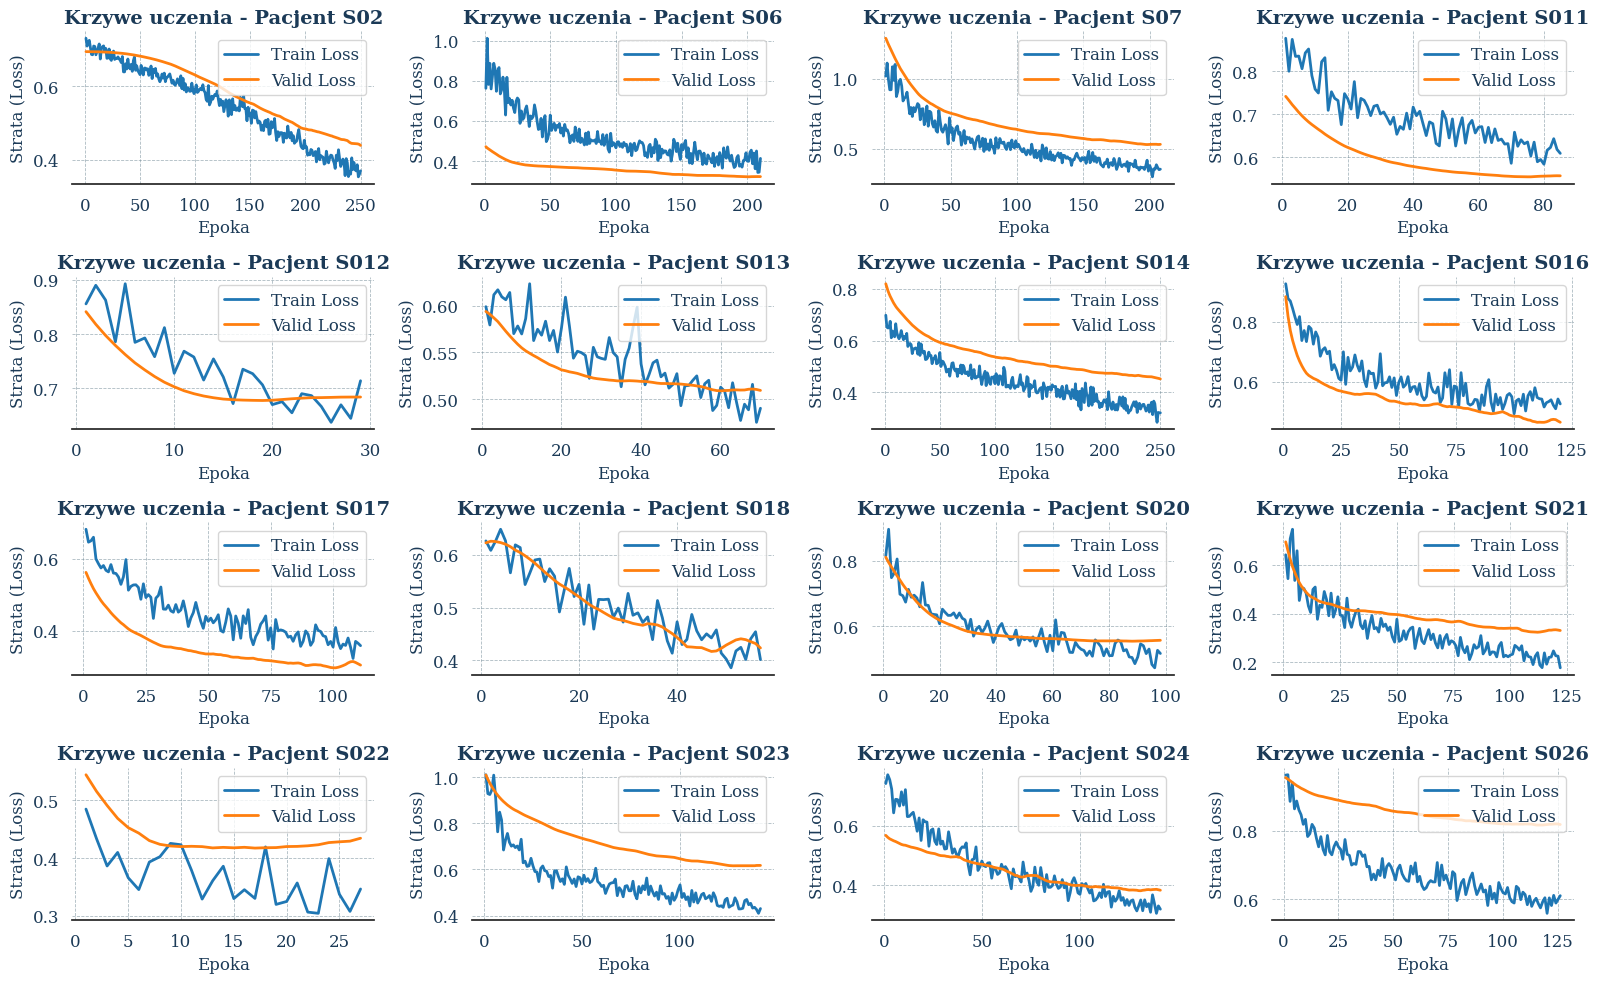

In [103]:
fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 10))
axes = axes.flatten()

for idx, subject in enumerate(subjects_list):
    ax = axes[idx]
    train_loss = learning_histories[subject]['train_loss']
    valid_loss = learning_histories[subject]['valid_loss']
    epochs = range(1, len(train_loss) + 1)
    
    # Rysowanie linii
    ax.plot(epochs, train_loss, label='Train Loss', color='#1f77b4', linewidth=2)
    ax.plot(epochs, valid_loss, label='Valid Loss', color='#ff7f0e', linewidth=2)
    
    # Formatowanie pojedynczego wykresu
    ax.set_title(f'Krzywe uczenia - Pacjent S0{subject}', fontsize=14, fontweight='bold')
    ax.set_xlabel('Epoka', fontsize=12)
    ax.set_ylabel('Strata (Loss)', fontsize=12)
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

# Cross-subject

In [17]:
results_cross = []

for subject in subjects_list:
    print(f"Trening modelu dla pacjenta {subject}...")

    train_datasets = []

    for sub_id in subjects_list:
        if sub_id == subject:
            # Ten pacjent to nasz hermetyczny zbiór testowy
            test_set = splitted[sub_id]
        else:
            # Pozostali pacjenci idą do wspólnego zbioru treningowego
            train_datasets.append(splitted[sub_id])

    train_set = BaseConcatDataset(train_datasets)

    print(f"Zbiór treningowy: {len(train_set)} epok (pacjenci {', '.join([s for s in subjects_list if s != subject])})")
    print(f"Zbiór testowy: {len(test_set)} epok (pacjent {subject})")

    y_train = [y for _, y, _ in train_set] 
    class_counts = np.bincount(y_train) 
    total_samples = len(y_train)

    w0 = total_samples / (2 * class_counts[0]) 
    w1 = total_samples / (2 * class_counts[1]) 
    weights = torch.tensor([w0, w1], dtype=torch.float).to(device)

    clf.set_params(
        criterion__weight=weights,
        train_split=ValidSplit(cv=0.2),
        callbacks=[early_stopping],
        optimizer__weight_decay=0.01
    )

    clf.fit(train_set, y=None)   

    y_pred = clf.predict(test_set)
    y_true = [y for _, y, _ in test_set]
    
    for true_val, pred_val in zip(y_true, y_pred):
        results_cross.append({'subject': subject, 'y_true': true_val, 'y_pred': pred_val})

Trening modelu dla pacjenta 1...
Zbiór treningowy: 5393 epok (pacjenci 2, 3, 4, 5, 6)
Zbiór testowy: 1044 epok (pacjent 1)
Re-initializing criterion because the following parameters were re-set: criterion__weight.
Re-initializing optimizer.
Re-initializing module.
Re-initializing criterion because the following parameters were re-set: weight.
Re-initializing optimizer.
  epoch    train_loss    valid_acc    valid_loss     dur
-------  ------------  -----------  ------------  ------
      1        0.4606       0.7822        0.4323  3.3002
      2        0.4219       0.7868        0.4243  3.0836
      3        0.4017       0.8137        0.4068  2.9836
      4        0.3952       0.8109        0.4133  2.9990
      5        0.3880       0.8193        0.4103  3.0333
      6        0.3732       0.8295        0.4016  3.3037
      7        0.3787       0.8128        0.4043  3.4235
      8        0.3731       0.8239        0.4092  3.5995
      9        0.3612       0.8091        0.4047  3.7386
 

# Results

In [104]:
df_results_within = pd.DataFrame(results_within)
#df_results_cross = pd.DataFrame(results_cross)

### Save to CSV

In [105]:
pd.DataFrame(df_results_within).to_csv("eeg_within.csv", index=False)
#pd.DataFrame(df_results_cross).to_csv("eeg_cross.csv", index=False)

## Wizki

In [106]:
df_within = pd.read_csv("eeg_within.csv")
df_cross = pd.read_csv("eeg_cross.csv")
results_table = []

### Metrics function

In [107]:
def calculate_metrics(df, experiment_name):
    for subject, group in df.groupby('subject'):
        y_true = group['y_true']
        y_pred = group['y_pred']
        
        acc = balanced_accuracy_score(y_true, y_pred) * 100
        f1 = f1_score(y_true, y_pred, pos_label=0)
        precision = precision_score(y_true, y_pred, pos_label=0)
        recall = recall_score(y_true, y_pred, pos_label=0)
        
        results_table.append({
            'Experiment': experiment_name,
            'Patient': f"S{int(subject):02d}",
            'Balanced Accuracy (%)': round(acc, 2),
            'F1-Score (ErrP)': round(f1, 3),
            'Precision (ErrP)': round(precision, 3),
            'Recall (ErrP)': round(recall, 3)
        })

In [108]:
calculate_metrics(df_within, 'Within-Subject')
calculate_metrics(df_cross, 'Cross-Subject')
df_results = pd.DataFrame(results_table)

In [109]:
print("--- TABELA ZBIORCZA WYNIKÓW ---")
print(df_results.to_string(index=False))

--- TABELA ZBIORCZA WYNIKÓW ---
    Experiment Patient  Balanced Accuracy (%)  F1-Score (ErrP)  Precision (ErrP)  Recall (ErrP)
Within-Subject     S02                  68.10            0.605             0.719          0.523
Within-Subject     S06                  68.34            0.333             0.226          0.636
Within-Subject     S07                  78.03            0.435             0.294          0.833
Within-Subject     S11                  56.66            0.579             0.492          0.705
Within-Subject     S12                  53.53            0.444             0.645          0.339
Within-Subject     S13                  77.00            0.753             0.814          0.700
Within-Subject     S14                  64.00            0.633             0.646          0.620
Within-Subject     S16                  59.86            0.574             0.574          0.574
Within-Subject     S17                  80.45            0.773             0.723          0.829
Within-S

In [110]:
pd.DataFrame(df_results.to_csv("eeg_results.csv", index=False))

""


### Confusion matrices

In [111]:
def plot_confusion_matrices(df, experiment_name, filename):
    fig, axes = plt.subplots(nrows=4, ncols=4, figsize=(16, 10))
    axes = axes.flatten()
    
    subjects_list = sorted(df['subject'].unique())
    
    for i, sub_id in enumerate(subjects_list):
        ax = axes[i]
        
        sub_data = df[df['subject'] == sub_id]
        y_true = sub_data['y_true']
        y_pred = sub_data['y_pred']
        
        cm = confusion_matrix(y_true, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['BŁĄD', 'Poprawne'])
        disp.plot(cmap='Blues', ax=ax, values_format='d', colorbar=False)
        
        ax.set_title(f"Pacjent S{int(sub_id):02d}", fontsize=14, fontweight='bold')
        ax.set_xlabel('Przewidziana klasa')
        ax.set_ylabel('Prawdziwa klasa')
    
    plt.suptitle(f"Macierze Pomyłek - {experiment_name}", fontsize=20, y=1.03)
    plt.tight_layout()
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()

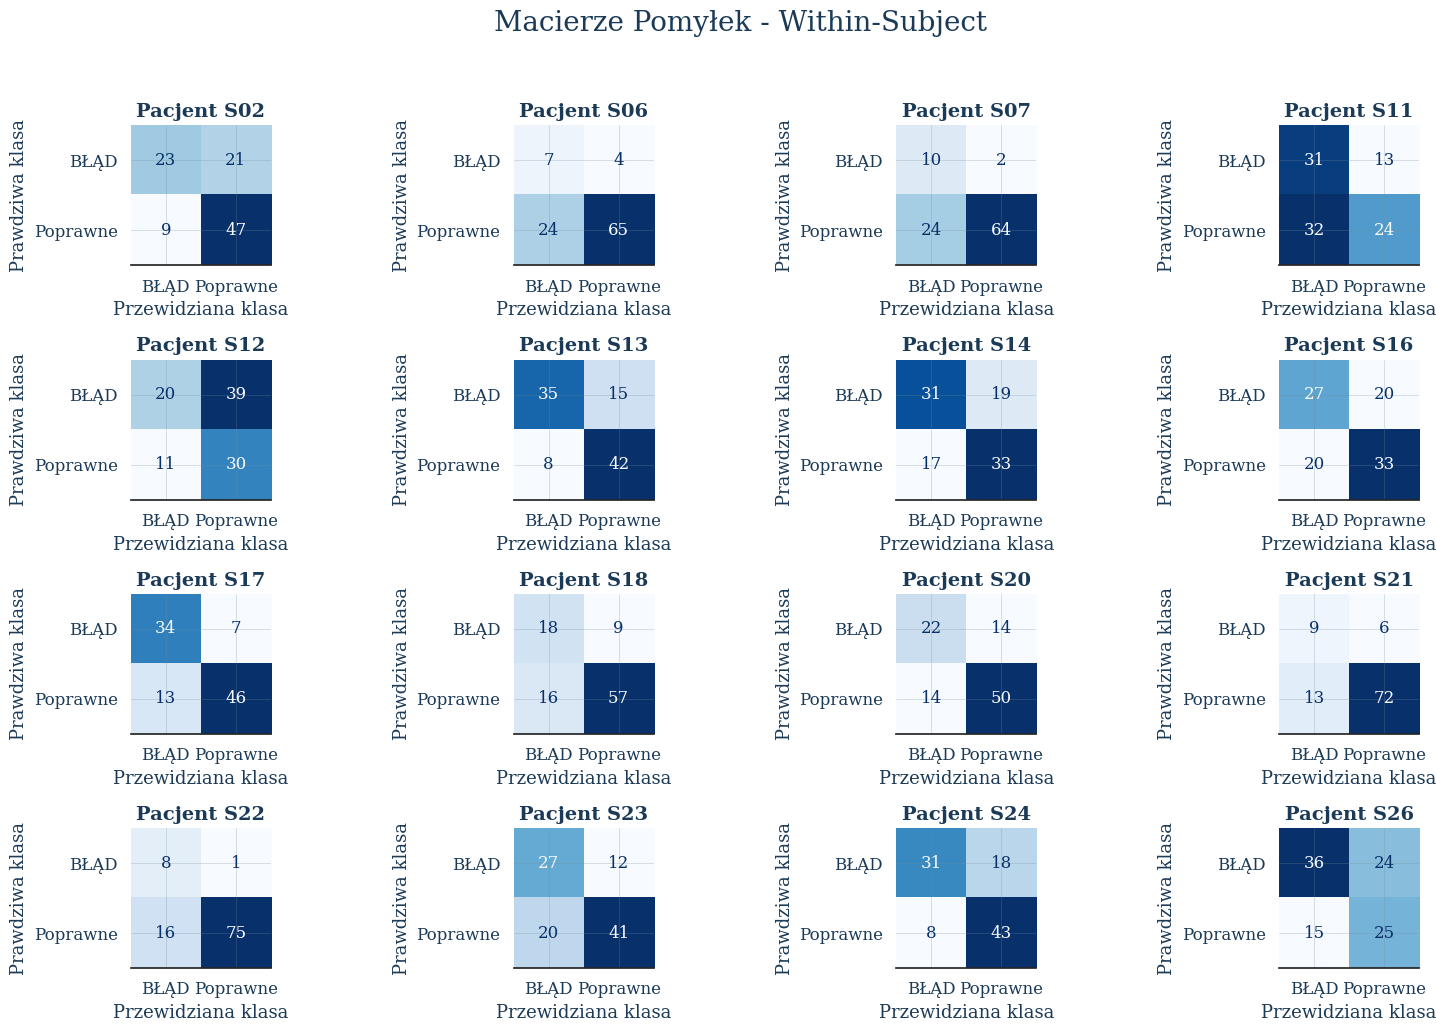

In [112]:
plot_confusion_matrices(df_within, 'Within-Subject', 'EEG_Within_Subject.png')
#plot_confusion_matrices(df_cross, 'Cross-Subject', 'EEG_Cross_Subject.png')

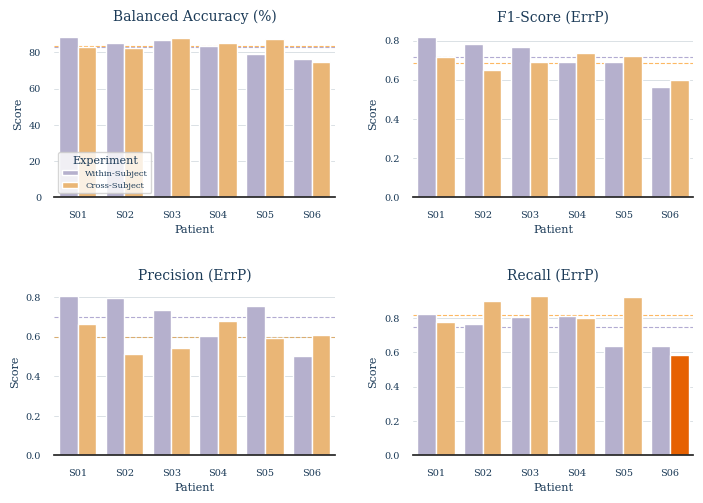

In [27]:
# Create subplots for each metric
df = pd.read_csv("eeg_results.csv")
metrics = df.columns[2:]
fig, axes = plt.subplots(2, 2, figsize=(7, 5))
axes = axes.flatten()

target_bar_index = 11
chosen_hex_color = "#e66101"

for i, metric in enumerate(metrics):
    sns.barplot(data=df, x='Patient', y=metric, hue='Experiment', ax=axes[i], palette=['#b2abd2', '#fdb863'])

    mean_within = df[df['Experiment'] == 'Within-Subject'][metric].mean()
    mean_cross = df[df['Experiment'] == 'Cross-Subject'][metric].mean()
    
    # Plot horizontal mean lines
    axes[i].axhline(mean_within, color='#b2abd2', linestyle='--', linewidth=0.8, zorder=0)
    axes[i].axhline(mean_cross, color='#fdb863', linestyle='--', linewidth=0.8, zorder=0)

    if metric == 'Recall (ErrP)':
        patches = axes[i].patches
        if len(patches) > target_bar_index:
            patches[target_bar_index].set_facecolor(chosen_hex_color)

    axes[i].set_title(metric, fontsize=10)
    axes[i].set_xlabel("Patient", fontsize=8)
    axes[i].set_ylabel("Score", fontsize=8)
    axes[i].tick_params(axis='both', which='major', labelsize=7)
    
    if i == 0:
        axes[i].legend(title='Experiment', fontsize=6, title_fontsize=8, loc='lower left')
    else:
        axes[i].get_legend().remove()

plt.tight_layout(pad=0.5, w_pad=2.0, h_pad=2.0)
plt.show()

# MISC

In [48]:
# 1. Definicja funkcji z DEBUGGEREM
def load_bci_session_debug(data_csv_path, labels_df, subject_id, session_id):
    df = pd.read_csv(data_csv_path)
    
    ch_names = list(df.columns)
    ch_names.remove('Time')
    ch_names.remove('FeedBackEvent')
    data = df[ch_names].values.T * 1e-6
    
    ch_types = ['eeg'] * 56 + ['eog']
    sfreq = 200.0 
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(data, info)
    
    feedback_indices = np.where(df['FeedBackEvent'] == 1)[0]
    
    prefix = f'S{subject_id:02d}_Sess{session_id:02d}'
    
    # Wyciągamy etykiety i dla pewności sortujemy je po ID (FB001, FB002, itd.)
    session_labels = labels_df[labels_df['IdFeedBack'].str.startswith(prefix)].copy()
    session_labels = session_labels.sort_values(by='IdFeedBack')
    
    predictions = session_labels['Prediction'].values
    
    print(f"DEBUG 1: Znaleziono {len(feedback_indices)} znaczników w sygnale.")
    print(f"DEBUG 2: Znaleziono {len(predictions)} etykiet w pliku TrainLabels.")
    print(f"DEBUG 3: Rozkład klas przed zmianą (powinny być 0 i 1): {np.unique(predictions, return_counts=True)}")
    
    # Przesunięcie o 1 - wymuszamy typ int, aby uniknąć błędów
    predictions_shifted = predictions.astype(int) + 1
    
    print(f"DEBUG 4: Rozkład klas po dodaniu jedynki (powinny być 1 i 2): {np.unique(predictions_shifted, return_counts=True)}")
    
    events = np.zeros((len(feedback_indices), 3), dtype=int)
    events[:, 0] = feedback_indices
    events[:, 2] = predictions_shifted
    
    mapping = {1: 'error', 2: 'good_feedback'}
    annot = mne.annotations_from_events(events, sfreq=sfreq, event_desc=mapping)
    raw.set_annotations(annot)
    
    # Podglądamy bezpośrednio to, co MNE fizycznie zapisało u siebie
    print(f"DEBUG 5: Adnotacje zapisane w MNE: {np.unique(raw.annotations.description, return_counts=True)}")
    
    return BaseDataset(raw, description={"subject": subject_id, "session": session_id})

# ==========================================
# 2. Uruchomienie testowe na problematycznej sesji
# ==========================================
# ==========================================
# TEST DIAGNOSTYCZNY - WERSJA OSTATECZNA
# ==========================================
print("--- START TESTU DIAGNOSTYCZNEGO ---")
labels_path = "TrainLabels.csv" 
labels_df = pd.read_csv(labels_path)
data_path_s14 = "bci_train/Data_S14_Sess01.csv" 

dataset_s14_debug = load_bci_session_debug(data_path_s14, labels_df, subject_id=14, session_id=1)

print("\n--- TEST WYCINANIA OKIEN ---")
concat_s14_debug = BaseConcatDataset([dataset_s14_debug])

# ZMIANA 1: Mapujemy na liczby DODATNIE (1 i 2), aby MNE ich nie zignorowało!
trial_mapping = {'error': 1, 'good_feedback': 2}
sfreq_raw = dataset_s14_debug.raw.info["sfreq"]

windows_dataset_s14_debug = create_windows_from_events(
    concat_s14_debug,
    trial_start_offset_samples=int(-0.2 * sfreq_raw),
    trial_stop_offset_samples=int(0.8 * sfreq_raw),
    mapping=trial_mapping,
    preload=True,
    drop_last_window=True
)

# ZMIANA 2: Przywracamy etykiety (Target) do wartości 0 i 1 dla PyTorcha
# Zmieniamy to bezpośrednio w tabeli metadanych, z której korzysta Braindecode
for ds in windows_dataset_s14_debug.datasets:
    ds.metadata['target'] = ds.metadata['target'] - 1

# Weryfikacja
y_labels = [y for _, y, _ in windows_dataset_s14_debug]
y_labels = np.array(y_labels)

print(f"\nOstateczne okna w Braindecode - klasa 0 (bad): {(y_labels == 1).sum()}")
print(f"Ostateczne okna w Braindecode - klasa 1 (good): {(y_labels == 2).sum()}")
print(f"Całkowita liczba okien: {len(y_labels)}")

--- START TESTU DIAGNOSTYCZNEGO ---
Creating RawArray with float64 data, n_channels=57, n_times=151001
    Range : 0 ... 151000 =      0.000 ...   755.000 secs
Ready.
DEBUG 1: Znaleziono 60 znaczników w sygnale.
DEBUG 2: Znaleziono 60 etykiet w pliku TrainLabels.
DEBUG 3: Rozkład klas przed zmianą (powinny być 0 i 1): (array([0, 1]), array([23, 37]))
DEBUG 4: Rozkład klas po dodaniu jedynki (powinny być 1 i 2): (array([1, 2]), array([23, 37]))
DEBUG 5: Adnotacje zapisane w MNE: (array(['error', 'good_feedback'], dtype='<U13'), array([23, 37]))

--- TEST WYCINANIA OKIEN ---
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]

Ostateczne okna w Braindecode - klasa 0 (bad): 23
Ostateczne okna w Braindecode - klasa 1 (good): 37
Całkowita liczba okien: 60


In [49]:
def load_bci_session(data_csv_path, labels_df, subject_id, session_id):
    df = pd.read_csv(data_csv_path)
    
    ch_names = list(df.columns)
    ch_names.remove('Time')
    ch_names.remove('FeedBackEvent')
    
    # Ładujemy jako Volty (standard MNE). 
    # W potoku preprocesingu Twój preprocessor "scale_to_uv" przywróci je do uV.
    data = df[ch_names].values.T
    
    ch_types = ['eeg'] * 56 + ['eog']
    sfreq = 200.0 
    
    info = mne.create_info(ch_names=ch_names, sfreq=sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(data, info)
    
    feedback_indices = np.where(df['FeedBackEvent'] == 1)[0]
    
    prefix = f'S{subject_id:02d}_Sess{session_id:02d}'
    session_labels = labels_df[labels_df['IdFeedBack'].str.startswith(prefix)]
    predictions = session_labels['Prediction'].values
    
    assert len(feedback_indices) == len(predictions), "Niezgodność liczby markerów i etykiet!"
    
    events = np.zeros((len(feedback_indices), 3), dtype=int)
    events[:, 0] = feedback_indices
    events[:, 2] = predictions
    
    # Adnotacje MNE używane przez Braindecode
    mapping = {0: 'error', 1: 'good_feedback'}
    annot = mne.annotations_from_events(events, sfreq=sfreq, event_desc=mapping)
    raw.set_annotations(annot)
    
    # Zapisujemy subject_id w opisie, aby potok wiedział, jak wykonać split("subject")
    description = {"subject": subject_id, "session": session_id}
    
    return BaseDataset(raw, description=description)

Wczytywanie surowych danych dla S14...
Creating RawArray with float64 data, n_channels=57, n_times=132001
    Range : 0 ... 132000 =      0.000 ...   660.000 secs
Ready.

--- STATYSTYKI PRZED PREPROCESINGIEM (Surowe) ---
Min: 3.112983e+02
Max: 5.641759e+02
Mean: 4.706787e+02
Liczba wartości NaN: 0
Liczba dokładnych zer: 0

Uruchamianie preprocesingu dla S14...
Applying average reference.
Applying a custom ('EEG',) reference.
Filtering raw data in 1 contiguous segment
Setting up band-pass filter from 1 - 30 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 1.00
- Lower transition bandwidth: 1.00 Hz (-6 dB cutoff frequency: 0.50 Hz)
- Upper passband edge: 30.00 Hz
- Upper transition bandwidth: 7.50 Hz (-6 dB cutoff frequency: 33.75 Hz)
- Filter length: 661 samples (3.305 s)


--- STATYS

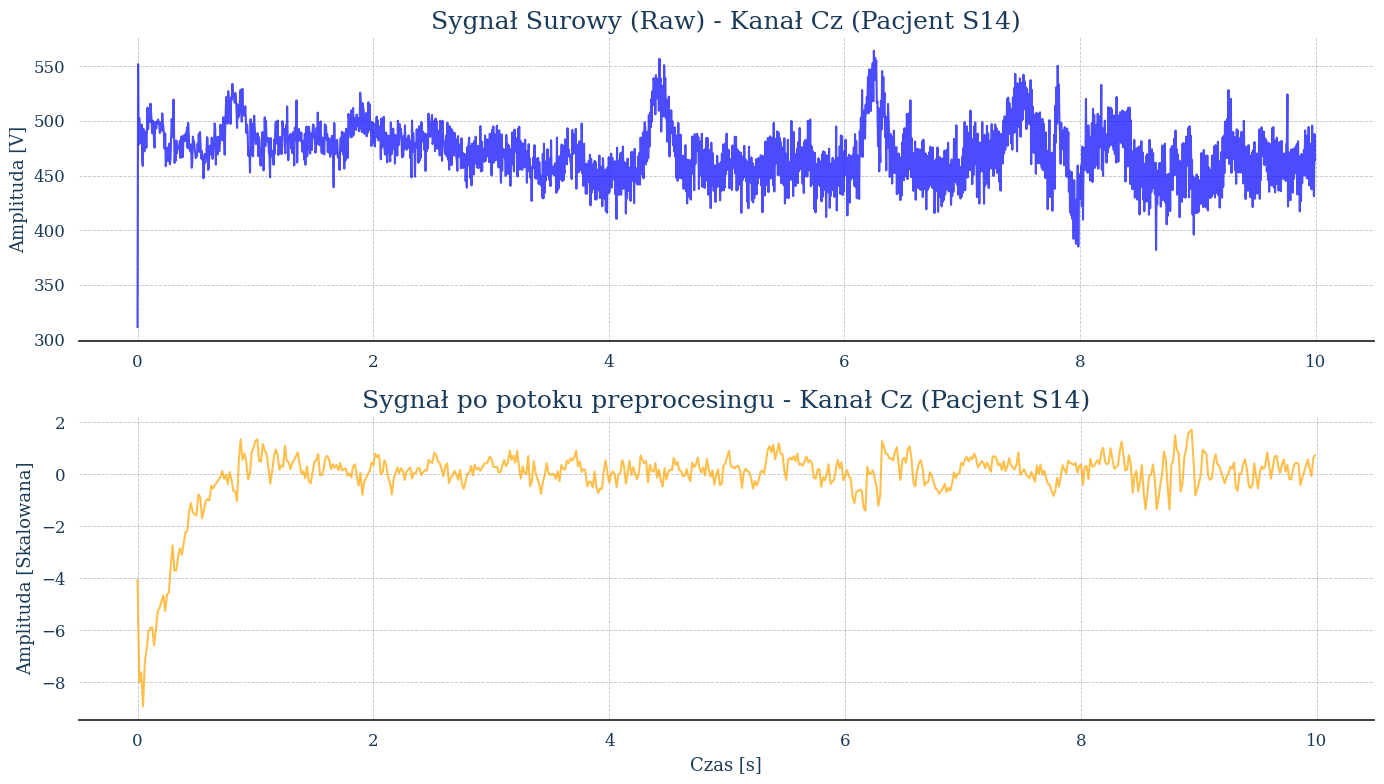

In [50]:
import matplotlib.pyplot as plt

# 1. Wczytanie etykiet i pojedynczej, problematycznej sesji
labels_path = "TrainLabels.csv" 
labels_df = pd.read_csv(labels_path)

# Zakładam, że masz ten plik w swoim katalogu
data_path_s14 = "bci_Train/Data_S02_Sess01.csv" 
print("Wczytywanie surowych danych dla S14...")
dataset_s14 = load_bci_session(data_path_s14, labels_df, subject_id=2, session_id=1)

# Wybieramy jeden kanał (np. Cz) i pierwsze 10 sekund sygnału
raw_before = dataset_s14.raw
ch_idx = raw_before.ch_names.index('Cz')
sfreq_raw = raw_before.info['sfreq']
stop_samp_raw = int(10 * sfreq_raw)

data_before, times_before = raw_before[ch_idx, 0:stop_samp_raw]

# 2. Obliczenie statystyk przed preprocesingiem
print("\n--- STATYSTYKI PRZED PREPROCESINGIEM (Surowe) ---")
print(f"Min: {data_before.min():.6e}")
print(f"Max: {data_before.max():.6e}")
print(f"Mean: {data_before.mean():.6e}")
print(f"Liczba wartości NaN: {np.isnan(data_before).sum()}")
print(f"Liczba dokładnych zer: {(data_before == 0).sum()}")

# 3. Przepuszczenie przez potok preprocesingu
concat_s14 = BaseConcatDataset([dataset_s14])

print("\nUruchamianie preprocesingu dla S14...")
# Korzystamy z listy preprocessors zdefiniowanej we wcześniejszym kroku
preprocess(concat_s14, preprocessors, n_jobs=1)

# Pobranie tych samych 10 sekund sygnału (uwaga: zmieniła się częstotliwość próbkowania na 64Hz)
raw_after = concat_s14.datasets[0].raw
sfreq_preproc = raw_after.info['sfreq']
stop_samp_preproc = int(10 * sfreq_preproc)

# Kanał Cz mógł zmienić indeks po odrzuceniu kanału EOG
ch_idx_after = raw_after.ch_names.index('Cz')
data_after, times_after = raw_after[ch_idx_after, 0:stop_samp_preproc]

# 4. Obliczenie statystyk po preprocesingu
print("\n--- STATYSTYKI PO PREPROCESINGU ---")
print(f"Min: {data_after.min():.6e}")
print(f"Max: {data_after.max():.6e}")
print(f"Mean: {data_after.mean():.6e}")
print(f"Liczba wartości NaN: {np.isnan(data_after).sum()}")
print(f"Liczba dokładnych zer: {(data_after == 0).sum()}")

# 5. Rysowanie wykresów porównawczych
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=False)

# Wykres górny: Surowy sygnał
axes[0].plot(times_before, data_before.T, color='blue', alpha=0.7)
axes[0].set_title('Sygnał Surowy (Raw) - Kanał Cz (Pacjent S14)')
axes[0].set_ylabel('Amplituda [V]')
axes[0].grid(True, linestyle='--', alpha=0.5)

# Wykres dolny: Sygnał po preprocesingu
# Dodaję walidację na wypadek samych NaNów, aby wykres się nie zawiesił
if np.isnan(data_after).all():
    axes[1].text(0.5, 0.5, 'Sygnał zepsuty (same wartości NaN)', 
                 horizontalalignment='center', verticalalignment='center', 
                 fontsize=14, color='red', transform=axes[1].transAxes)
else:
    axes[1].plot(times_after, data_after.T, color='orange', alpha=0.7)

axes[1].set_title('Sygnał po potoku preprocesingu - Kanał Cz (Pacjent S14)')
axes[1].set_xlabel('Czas [s]')
axes[1].set_ylabel('Amplituda [Skalowana]')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [51]:
# Upewniamy się, że mamy dostęp do gotowych epok dla pacjenta S14
# Jeśli masz już zmienną wygenerowaną dla S14, możesz pominąć proces windowingu

print("Wycinanie okien dla S14 do sprawdzenia etykiet...")
trial_mapping = {'error': 0, 'good_feedback': 1}
sfreq = concat_s14.datasets[0].raw.info["sfreq"]
windows_dataset_s14 = create_windows_from_events(
    concat_s14,
    trial_start_offset_samples=int(-0.2 * sfreq),
    trial_stop_offset_samples=int(0.8 * sfreq),
    mapping=trial_mapping,
    preload=True,
    drop_last_window=True
)

# Zbieranie wszystkich etykiet
y_labels = [y for _, y, _ in windows_dataset_s14]
y_labels = np.array(y_labels)

print(f"\nCałkowita liczba okien dla S14: {len(y_labels)}")
print(f"Liczba okien klasy 1 (bad feedback): {(y_labels == 0).sum()}")
print(f"Liczba okien klasy 2 (good feedback): {(y_labels == 1).sum()}")

Wycinanie okien dla S14 do sprawdzenia etykiet...
Used Annotations descriptions: [np.str_('error'), np.str_('good_feedback')]

Całkowita liczba okien dla S14: 60
Liczba okien klasy 1 (bad feedback): 10
Liczba okien klasy 2 (good feedback): 50


### Analysis (full chat)

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Zmienne z Twojego pipeline'u
t_min = -0.2
t_max = 0.8
channel_name = 'FCz' # Zmień na 'Cz', jeśli FCz nie jest dostępne

# Pobranie indeksu kanału z oryginalnego obiektu
ch_names = data.datasets[0].raw.info["ch_names"]
ch_idx = ch_names.index(channel_name)

# Podział na pacjentów
splitted = windows_dataset.split("subject")

# Słowniki na wyciągnięte dane błędów (Klasa 0)
errp_data = {}

print("Ekstrakcja epok błędów dla pacjentów 1, 4 i 6...")
for sub_id in subjects_list:
    subject_set = splitted[sub_id]
    X_errp = []
    
    for X, y, _ in subject_set:
        if y == 0:  # Interesują nas tylko błędy
            X_errp.append(X)
            
    errp_data[sub_id] = np.array(X_errp)

# Tworzenie osi czasu
n_samples = errp_data['1'].shape[2]
time_axis = np.linspace(t_min, t_max, n_samples)

# ---------------------------------------------------------
# WYKRES 1: PORÓWNAWCZY GRAND AVERAGE (S01 vs S04 vs S06)
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(12, 6))

# S01 - Złoty standard (Zielony)
evoked_1 = np.mean(errp_data['1'], axis=0)[ch_idx]
ax.plot(time_axis, evoked_1, label='S01 (Wzorzec)', color='#2ca02c', linewidth=2.5)

# S04 - Podejrzenie szumu (Czerwony)
evoked_4 = np.mean(errp_data['4'], axis=0)[ch_idx]
ax.plot(time_axis, evoked_4, label='S04 (Podejrzenie szumu)', color='#d62728', linewidth=2.5, alpha=0.8)

# S06 - Podejrzenie przesunięcia (Pomarańczowy)
evoked_6 = np.mean(errp_data['6'], axis=0)[ch_idx]
ax.plot(time_axis, evoked_6, label='S06 (Podejrzenie anomalii czasu)', color='#ff7f0e', linewidth=2.5, alpha=0.8)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_title(f'Grand Average (Klasa 0 - Błąd) | Kanał: {channel_name}', fontsize=14, fontweight='bold')
ax.set_xlabel('Czas [s]')
ax.set_ylabel('Amplituda znormalizowana')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


Ekstrakcja epok błędów dla pacjentów 1, 4 i 6...


In [84]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parametry czasowe i przestrzenne
t_min = -0.2
t_max = 0.8
channel_name = 'FCz' # Kanał centralny, optymalny dla ErrP

# Pobranie indeksu kanału
ch_names = data.datasets[0].raw.info["ch_names"]
ch_idx = ch_names.index(channel_name)

# 2. Ekstrakcja danych dla całej grupy badawczej
splitted = windows_dataset.split("subject")
subjects_list = ['1', '2', '3', '4', '5', '6']
errp_data = {}

print("Ekstrakcja epok błędów (Klasa 0) dla wszystkich pacjentów...")
for sub_id in subjects_list:
    subject_set = splitted[sub_id]
    X_errp = []
    
    for X, y, _ in subject_set:
        if y == 0:  
            X_errp.append(X)
            
    errp_data[sub_id] = np.array(X_errp)

# 3. Oś czasu
n_samples = errp_data['1'].shape[2]
time_axis = np.linspace(t_min, t_max, n_samples)

# 4. Generowanie zbiorczego wykresu
fig, ax = plt.subplots(figsize=(14, 7))

# Słownik stylów: "rdzeń" rysujemy cieniej i chłodniej, problemy grubiej i jaskrawiej
styles = {
    '1': {'color': '#1f77b4', 'lw': 1.5, 'alpha': 0.5, 'label': 'S01 (Rdzeń)'},
    '2': {'color': '#2ca02c', 'lw': 1.5, 'alpha': 0.5, 'label': 'S02 (Rdzeń)'},
    '3': {'color': '#9467bd', 'lw': 1.5, 'alpha': 0.5, 'label': 'S03 (Rdzeń)'},
    '5': {'color': '#8c564b', 'lw': 1.5, 'alpha': 0.5, 'label': 'S05 (Rdzeń)'},
    '4': {'color': '#d62728', 'lw': 3.0, 'alpha': 0.9, 'label': 'S04 (Podejrzenie zaszumienia)'},
    '6': {'color': '#ff7f0e', 'lw': 3.0, 'alpha': 0.9, 'label': 'S06 (Podejrzenie przesunięcia fazy)'}
}

for sub_id in subjects_list:
    # Obliczenie średniej (Grand Average) dla danego pacjenta i wybranie jednego kanału
    evoked = np.mean(errp_data[sub_id], axis=0)[ch_idx]
    sty = styles[sub_id]
    
    # Rysowanie krzywej
    ax.plot(
        time_axis, 
        evoked, 
        color=sty['color'], 
        linewidth=sty['lw'], 
        alpha=sty['alpha'], 
        label=sty['label']
    )

# Formatowanie osi i legendy
ax.axvline(x=0, color='black', linestyle='--', linewidth=1.5, label='Moment błędu')
ax.set_title(f'Zbiorczy Grand Average ErrP (Klasa 0) | Kanał: {channel_name}', fontsize=16, fontweight='bold')
ax.set_xlabel('Czas [sekundy]', fontsize=12)
ax.set_ylabel('Amplituda znormalizowana', fontsize=12)
ax.legend(loc='upper right', fontsize=10, framealpha=0.9)
ax.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Ekstrakcja epok błędów (Klasa 0) dla wszystkich pacjentów...


In [83]:

# ---------------------------------------------------------
# WYKRES 2: OBRAZ ERP (HEATMAPA) POJEDYNCZYCH EPOK DLA S04
# ---------------------------------------------------------
# Pobieramy wszystkie epoki błędów dla pacjenta 4 tylko dla wybranego kanału
s04_trials = errp_data['6'][:, ch_idx, :]

fig, ax = plt.subplots(figsize=(10, 8))

# Rysujemy heatmapę: oś X to czas, oś Y to kolejne wystąpienia błędu
cax = ax.imshow(
    s04_trials, 
    aspect='auto', 
    origin='lower', 
    extent=[t_min, t_max, 1, s04_trials.shape[0]],
    cmap='RdBu_r' # Czerwony to wartości dodatnie, niebieski ujemne
)

ax.axvline(x=0, color='black', linestyle='--', linewidth=1)
ax.set_title(f'S06 - Heatmapa pojedynczych epok błędów ({channel_name})', fontsize=14, fontweight='bold')
ax.set_xlabel('Czas [s]')
ax.set_ylabel('Numer epoki testowej (chronologicznie)')
fig.colorbar(cax, ax=ax, label='Amplituda')

plt.tight_layout()
plt.show()

In [85]:
import mne
import numpy as np
import matplotlib.pyplot as plt

# 1. Konfiguracja osi czasu (od 0.20s do 0.40s z krokiem 0.01s)
times = np.arange(0.20, 0.41, 0.01)
t_min = -0.2

# 2. Pobranie metadanych przestrzennych (Info)
info = data.datasets[0].raw.info

# 3. Ekstrakcja danych
splitted = windows_dataset.split("subject")
subjects_list = ['1', '2', '3', '4', '5', '6']

# 4. Przygotowanie dużej siatki wykresów (6 wierszy x 21 kolumn)
# Rozmiar figury jest bardzo szeroki, aby pomieścić głowy bez nachodzenia na siebie
fig, axes = plt.subplots(nrows=len(subjects_list), ncols=len(times), figsize=(28, 10))

print("Generowanie analizy czasowo-przestrzennej (200-400 ms)...")

for i, sub_id in enumerate(subjects_list):
    subject_set = splitted[sub_id]
    X_errp = []
    
    # Wyciągamy epoki błędów (Klasa 0)
    for X, y, _ in subject_set:
        if y == 0:  
            X_errp.append(X)
            
    # Uśrednienie epok (Grand Average)
    evoked_data = np.mean(np.array(X_errp), axis=0)
    evoked = mne.EvokedArray(evoked_data, info, tmin=t_min)
    
    for j, t in enumerate(times):
        ax = axes[i, j]
        
        # Rysowanie mapy w konkretnej klatce (czasie t)
        # UWAGA: W MNE < 1.2 użyj vmin=-1.5, vmax=1.5 zamiast vlim=(-1.5, 1.5)
        evoked.plot_topomap(
            times=[t], 
            axes=ax, 
            vlim=(-1.5, 1.5), 
            cmap='RdBu_r',     
            colorbar=False, 
            show=False,
            time_format='' # Ukrywamy domyślne podpisy
        )
        
        # Formatowanie brzegów siatki dla czytelności
        if i == 0:
            # Podpisy czasu nad pierwszą kolumną
            ax.set_title(f'{t*1000:.0f} ms', fontsize=11, fontweight='bold')
        if j == 0:
            # Podpisy pacjentów po lewej stronie
            ax.set_ylabel(f'S0{sub_id}', fontsize=14, fontweight='bold')

# 5. Globalny pasek kolorów
sm = plt.cm.ScalarMappable(cmap='RdBu_r', norm=plt.Normalize(vmin=-1.5, vmax=1.5))
sm.set_array([])
cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7]) 
fig.colorbar(sm, cax=cbar_ax, label='Amplituda znormalizowana')

plt.suptitle("Propagacja Przestrzenna Fali ErrP (200 ms - 400 ms)", fontsize=22, fontweight='bold', y=0.98)
# Ciasne ułożenie marginesów, żeby usunąć białe luki
plt.subplots_adjust(left=0.03, right=0.9, top=0.9, bottom=0.05, wspace=0.0, hspace=0.1)
plt.show()

Generowanie analizy czasowo-przestrzennej (200-400 ms)...


### GridSearch

In [101]:
import numpy as np
import pandas as pd
import torch
import torch.optim as optim
from skorch.callbacks import EarlyStopping, LRScheduler
from skorch.dataset import ValidSplit
from sklearn.model_selection import ParameterGrid
from sklearn.metrics import f1_score

# 1. Definicja pełnej siatki hiperparametrów (4 x 4 x 4 = 64 kombinacje)
param_grid = {
    'lr': [1e-3, 5e-4, 1e-4, 5e-5],
    'optimizer__weight_decay': [0.05, 0.01, 0.005, 0.001],
    'module__drop_prob': [0.2, 0.3, 0.4, 0.5, 0.6] 
}

full_search_grid = list(ParameterGrid(param_grid))
all_runs_history = [] 

print("==========================================================================================")
print(f"ROZPOCZYNAM PEŁNY GRID SEARCH")
print(f"Kombinacji: {len(full_search_grid)} | Pacjentów: {len(subjects_list)} | Łączna liczba treningów: {len(full_search_grid) * len(subjects_list)}")
print("==========================================================================================")

# 2. Główna pętla Grid Search
for i, params in enumerate(full_search_grid):
    print(f"\n[ Kombinacja {i+1}/{len(full_search_grid)} ] Testowane parametry: {params}")
    
    current_combination_f1_scores = {}
    
    # Trenujemy wszystkich pacjentów na obecnej kombinacji parametrów
    for subject in subjects_list:
        
        # --- BEZPIECZNY PODZIAŁ DANYCH CHRONOLOGICZNIE ---
        subj_sessions = splitted[subject].split('session')
        session_keys = sorted(subj_sessions.keys(), key=int)
        split_idx = int(len(session_keys) * train_percent)
        
        train_keys = session_keys[:split_idx]
        test_keys = session_keys[split_idx:]
        
        train_set = BaseConcatDataset([subj_sessions[k] for k in train_keys])
        test_set = BaseConcatDataset([subj_sessions[k] for k in test_keys])

        # --- KALKULACJA WAG KLAS ---
        y_train = [y for _, y, _ in train_set] 
        class_counts = np.bincount(y_train) 
        total_samples = len(y_train)
        w0 = total_samples / (2 * class_counts[0]) 
        w1 = total_samples / (2 * class_counts[1]) 
        weights = torch.tensor([w0, w1], dtype=torch.float).to(device)

        # --- ZABEZPIECZENIA PRZED PRZEUCZENIEM ---
        early_stopping = EarlyStopping(monitor='valid_loss', patience=10, lower_is_better=True)
        cosine_annealing = LRScheduler(policy='CosineAnnealingLR', T_max=49)

        # NOWE: Pobieramy pierwszą próbkę z train_set, aby poznać wymiary macierzy
        sample_X, _, _ = train_set[0]
        n_chans = sample_X.shape[0] # Liczba elektrod (np. 8)
        n_times = sample_X.shape[1] # Długość epoki w czasie (np. 150)
        n_classes = 2

        # --- WSTRZYKNIĘCIE PARAMETRÓW I TRENING ---
        clf.set_params(
            criterion__weight=weights,
            train_split=ValidSplit(cv=0.2),
            callbacks=[early_stopping, cosine_annealing],
            optimizer=optim.AdamW,
            
            # NOWE: Sztywne przypomnienie wymiarów podczas przebudowy modelu
            module__n_chans=n_chans, 
            module__n_times=n_times,   
            module__n_outputs=n_classes,
            
            **params # Rozpakowanie siatki (w tym nieszczęsnego dropoutu)
        )

        clf.fit(train_set, y=None)   

        # --- EWALUACJA (F1-SCORE MACRO) ---
        y_pred = clf.predict(test_set)
        y_true = [y for _, y, _ in test_set]
        
        subject_f1 = f1_score(y_true, y_pred, average='macro') 
        current_combination_f1_scores[f'S0{subject}_f1'] = subject_f1 
        print(f"   -> S0{subject} | F1-Score: {subject_f1:.4f}")

    # --- ZAPIS REKORDU DLA OBECNEJ KOMBINACJI ---
    avg_f1_for_combination = np.mean(list(current_combination_f1_scores.values()))
    print(f"ŚREDNI F1-SCORE DLA KOMBINACJI {i+1}: {avg_f1_for_combination:.4f}")
    
    run_record = {
        'run_id': i + 1,
        'avg_f1': avg_f1_for_combination,
        **params, 
        **current_combination_f1_scores 
    }
    all_runs_history.append(run_record)

print("\n==========================================================================================")
print("WYSZUKIWANIE ZAKOŃCZONE. Generowanie raportu...")

# 3. Zapis wyników do pliku CSV
results_df = pd.DataFrame(all_runs_history)
results_df = results_df.sort_values(by='avg_f1', ascending=False).reset_index(drop=True)

# Formatowanie nazw kolumn dla lepszej czytelności w Excelu
results_df.rename(columns={'optimizer__weight_decay': 'weight_decay', 'module__drop_prob': 'dropout'}, inplace=True)

file_name = 'eeg_grid_search_results.csv'
results_df.to_csv(file_name, index=False)

print(f"Zapisano pełną historię {len(full_search_grid)} prób do pliku: '{file_name}'.")
print("\nTOP 3 NAJLEPSZE KOMBINACJE:")
print(results_df[['run_id', 'avg_f1', 'lr', 'weight_decay', 'dropout']].head(3).to_string(index=False))

ROZPOCZYNAM PEŁNY GRID SEARCH
Kombinacji: 80 | Pacjentów: 6 | Łączna liczba treningów: 480

[ Kombinacja 1/80 ] Testowane parametry: {'lr': 0.001, 'module__drop_prob': 0.2, 'optimizer__weight_decay': 0.05}
  epoch    train_loss    valid_acc    valid_loss      lr     dur
-------  ------------  -----------  ------------  ------  ------
      1        0.6829       0.2927        0.6907  0.0010  0.8760
      2        0.6310       0.4512        0.6873  0.0010  0.5407
      3        0.5814       0.6646        0.6819  0.0010  0.4788
      4        0.5392       0.6890        0.6755  0.0010  0.4455
      5        0.5083       0.7866        0.6678  0.0010  0.4405
      6        0.4670       0.8171        0.6591  0.0010  0.4285
      7        0.4144       0.8110        0.6491  0.0010  0.4304
      8        0.3826       0.7927        0.6400  0.0010  0.4446
      9        0.3449       0.7988        0.6258  0.0009  0.4387
     10        0.3377       0.7866        0.6159  0.0009  0.4333
     11       